### A MNIST-like fashion product database

In this, we classify the images into respective classes given in the dataset. We use a Neural Net and a Deep Neural Net in Keras to solve this and check the accuracy scores.

### Load tensorflow

In [0]:
import tensorflow as tf
import numpy as np
tf.set_random_seed(42)

In [92]:
tf.__version__

'1.14.0'

### Collect Data

In [0]:
import keras

In [0]:
(trainX, trainY), (testX, testY) = keras.datasets.fashion_mnist.load_data()

In [95]:
trainX.shape

(60000, 28, 28)

In [97]:
len(trainY)

60000

In [103]:
print(testY[0:5])

[9 2 1 1 6]


In [99]:
testY.shape

(10000,)

In [0]:
trainX = trainX / 255.0

testX = testX / 255.0

### Convert both training and testing labels into one-hot vectors.

**Hint:** check **tf.keras.utils.to_categorical()**

In [105]:
trainY = tf.keras.utils.to_categorical(trainY)
trainY

array([[0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [106]:
testY = tf.keras.utils.to_categorical(testY)
testY

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [107]:
print(trainY.shape)
print('First 5 examples now are: ', trainY[0:5])

(60000, 10)
First 5 examples now are:  [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


### Visualize the data

Plot first 10 images in the triaining set and their labels.

In [0]:
import matplotlib.pyplot as plt

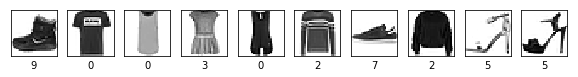

In [109]:
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(10,10,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(trainX[i], cmap=plt.cm.binary)
    plt.xlabel(np.argmax(trainY[i]))
plt.show()

### Build a neural Network with a cross entropy loss function and sgd optimizer in Keras. The output layer with 10 neurons as we have 10 classes.

In [0]:
from keras.models import Sequential
from keras.layers.core import Dense,Dropout,Activation,Flatten

In [0]:
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(10,activation ='sigmoid'))


In [0]:
model.compile(optimizer='sgd',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

### Execute the model using model.fit()

In [121]:
model.fit(trainX,trainY,batch_size=100,epochs=12,verbose=1,validation_data=(testX,testY))

Train on 60000 samples, validate on 10000 samples
Epoch 1/12
60000/60000 [==============================] - 3s 46us/step - loss: 1.4002 - acc: 0.5817 - val_loss: 0.9721 - val_acc: 0.6911
Epoch 2/12
60000/60000 [==============================] - 3s 42us/step - loss: 0.8495 - acc: 0.7338 - val_loss: 0.7931 - val_acc: 0.7415
Epoch 3/12
60000/60000 [==============================] - 3s 42us/step - loss: 0.7355 - acc: 0.7690 - val_loss: 0.7214 - val_acc: 0.7676
Epoch 4/12
60000/60000 [==============================] - 3s 42us/step - loss: 0.6773 - acc: 0.7866 - val_loss: 0.6763 - val_acc: 0.7806
Epoch 5/12
60000/60000 [==============================] - 3s 42us/step - loss: 0.6395 - acc: 0.7982 - val_loss: 0.6465 - val_acc: 0.7919
Epoch 6/12
60000/60000 [==============================] - 3s 42us/step - loss: 0.6122 - acc: 0.8063 - val_loss: 0.6241 - val_acc: 0.7979
Epoch 7/12
60000/60000 [==============================] - 3s 42us/step - loss: 0.5915 - acc: 0.8110 - val_loss: 0.6050 - val_acc

In [122]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_4 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_18 (Dense)             (None, 10)                7850      
Total params: 7,850
Trainable params: 7,850
Non-trainable params: 0
_________________________________________________________________




### In the above Neural Network model add Batch Normalization layer after the input layer and repeat the steps.

In [0]:
from keras.layers.normalization import BatchNormalization
model1 = Sequential()
model1.add(Flatten(input_shape=(28, 28)))
model1.add(BatchNormalization())  #Batch Normalization
model1.add(Dense(10,activation ='sigmoid'))

### Execute the model

In [0]:
model1.compile(optimizer='sgd',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [126]:
model1.fit(trainX,trainY,batch_size=100,epochs=12,verbose=1,validation_data=(testX,testY))

Train on 60000 samples, validate on 10000 samples
Epoch 1/12
60000/60000 [==============================] - 3s 47us/step - loss: 0.4351 - acc: 0.8472 - val_loss: 0.4652 - val_acc: 0.8378
Epoch 2/12
60000/60000 [==============================] - 3s 52us/step - loss: 0.4270 - acc: 0.8515 - val_loss: 0.4599 - val_acc: 0.8381
Epoch 3/12
60000/60000 [==============================] - 3s 52us/step - loss: 0.4221 - acc: 0.8518 - val_loss: 0.4566 - val_acc: 0.8398
Epoch 4/12
60000/60000 [==============================] - 3s 52us/step - loss: 0.4198 - acc: 0.8537 - val_loss: 0.4544 - val_acc: 0.8412
Epoch 5/12
60000/60000 [==============================] - 3s 52us/step - loss: 0.4170 - acc: 0.8537 - val_loss: 0.4528 - val_acc: 0.8411
Epoch 6/12
60000/60000 [==============================] - 3s 51us/step - loss: 0.4134 - acc: 0.8553 - val_loss: 0.4509 - val_acc: 0.8419
Epoch 7/12
60000/60000 [==============================] - 3s 53us/step - loss: 0.4124 - acc: 0.8556 - val_loss: 0.4493 - val_acc

In [128]:
model1.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_5 (Flatten)          (None, 784)               0         
_________________________________________________________________
batch_normalization_3 (Batch (None, 784)               3136      
_________________________________________________________________
dense_19 (Dense)             (None, 10)                7850      
Total params: 10,986
Trainable params: 9,418
Non-trainable params: 1,568
_________________________________________________________________


### Customize the learning rate to 0.001 in sgd optimizer and run the model

In [0]:
from keras import optimizers
sgd = optimizers.SGD(lr=0.001)

In [0]:
model1.compile(optimizer=sgd,
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [131]:
model1.fit(trainX,trainY,batch_size=200,epochs=12,verbose=1,validation_data=(testX,testY))

Train on 60000 samples, validate on 10000 samples
Epoch 1/12
60000/60000 [==============================] - 2s 35us/step - loss: 0.3954 - acc: 0.8609 - val_loss: 0.4439 - val_acc: 0.8447
Epoch 2/12
60000/60000 [==============================] - 2s 29us/step - loss: 0.3946 - acc: 0.8617 - val_loss: 0.4435 - val_acc: 0.8450
Epoch 3/12
60000/60000 [==============================] - 2s 29us/step - loss: 0.3943 - acc: 0.8612 - val_loss: 0.4434 - val_acc: 0.8447
Epoch 4/12
60000/60000 [==============================] - 2s 29us/step - loss: 0.3946 - acc: 0.8610 - val_loss: 0.4432 - val_acc: 0.8447
Epoch 5/12
60000/60000 [==============================] - 2s 29us/step - loss: 0.3942 - acc: 0.8613 - val_loss: 0.4432 - val_acc: 0.8447
Epoch 6/12
60000/60000 [==============================] - 2s 29us/step - loss: 0.3945 - acc: 0.8616 - val_loss: 0.4432 - val_acc: 0.8451
Epoch 7/12
60000/60000 [==============================] - 2s 28us/step - loss: 0.3946 - acc: 0.8619 - val_loss: 0.4430 - val_acc

### Build the Neural Network model with 3 Dense layers with 100,100,10 neurons respectively in each layer. Use cross entropy loss function and singmoid as activation in the hidden layers and softmax as activation function in the output layer. Use sgd optimizer with learning rate 0.03.

In [0]:
model_1 = keras.Sequential()
model_1.add(Flatten(input_shape=(28, 28)))
model_1.add(Dense(100,activation='sigmoid'))
model_1.add(Dense(100,activation='sigmoid'))
model_1.add(Dense(10,activation='softmax'))

In [0]:
sgd = optimizers.SGD(lr=0.03)

## Review model

In [0]:
model_1.compile(optimizer=sgd,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

### Run the model

In [135]:
model_1.fit(trainX,trainY,batch_size=200,nb_epoch=12,verbose=1,validation_data=(testX,testY))

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:1: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.
  """Entry point for launching an IPython kernel.


Train on 60000 samples, validate on 10000 samples
Epoch 1/12
60000/60000 [==============================] - 2s 33us/step - loss: 2.2045 - acc: 0.3532 - val_loss: 2.0587 - val_acc: 0.5553
Epoch 2/12
60000/60000 [==============================] - 2s 27us/step - loss: 1.8580 - acc: 0.5586 - val_loss: 1.6636 - val_acc: 0.5891
Epoch 3/12
60000/60000 [==============================] - 2s 27us/step - loss: 1.5119 - acc: 0.5874 - val_loss: 1.3825 - val_acc: 0.5839
Epoch 4/12
60000/60000 [==============================] - 2s 27us/step - loss: 1.2761 - acc: 0.6261 - val_loss: 1.1899 - val_acc: 0.6500
Epoch 5/12
60000/60000 [==============================] - 2s 27us/step - loss: 1.1154 - acc: 0.6601 - val_loss: 1.0582 - val_acc: 0.6688
Epoch 6/12
60000/60000 [==============================] - 2s 27us/step - loss: 1.0027 - acc: 0.6867 - val_loss: 0.9637 - val_acc: 0.6914
Epoch 7/12
60000/60000 [==============================] - 2s 27us/step - loss: 0.9184 - acc: 0.7044 - val_loss: 0.8921 - val_acc

In [136]:
model_1.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_6 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_20 (Dense)             (None, 100)               78500     
_________________________________________________________________
dense_21 (Dense)             (None, 100)               10100     
_________________________________________________________________
dense_22 (Dense)             (None, 10)                1010      
Total params: 89,610
Trainable params: 89,610
Non-trainable params: 0
_________________________________________________________________
